# Raw Data Summary for Phase 1

This notebook profiles the raw telemetry files in `Data/files_csv` to answer four questions:
- what does the raw data look like?
- how complete is it?
- how variable is it?
- is it credible enough for monitoring?

In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'Data' / 'files_csv').exists() and (REPO_ROOT.parent / 'Data' / 'files_csv').exists():
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / 'Data' / 'files_csv'
TEMPERATURE_PATH = DATA_DIR / 'temperature_raw.csv'

if TEMPERATURE_PATH.exists():
    files = [TEMPERATURE_PATH]
    print(f'Using existing temperature-only input: {TEMPERATURE_PATH}')
else:
    files = sorted(f for f in DATA_DIR.glob('*.csv') if f != TEMPERATURE_PATH)
    print(f'Found {len(files)} source CSV files in {DATA_DIR}')

print(f'Repository root: {REPO_ROOT}')
files[:3]

Using existing temperature-only input: c:\Users\mcphe\Dropbox\Business\Data\sensor_project\Data\files_csv\temperature_raw.csv
Repository root: c:\Users\mcphe\Dropbox\Business\Data\sensor_project


Using existing temperature-only input: c:\Users\mcphe\Dropbox\Business\Data\sensor_project\Data\files_csv\temperature_raw.csv
Repository root: c:\Users\mcphe\Dropbox\Business\Data\sensor_project


[WindowsPath('c:/Users/mcphe/Dropbox/Business/Data/sensor_project/Data/files_csv/temperature_raw.csv')]

In [11]:
frames = []

for f in files:
    df = pd.read_csv(f)
    required = {'Time', 'DeviceId', 'Sensor', 'Value'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'{f.name} missing columns: {sorted(missing)}')

    df = df.copy()
    df['source_file'] = f.name
    df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df['DeviceId'] = df['DeviceId'].astype(str)
    df['Sensor'] = df['Sensor'].astype(str)
    df['ts_utc'] = pd.to_datetime(df['Time'], unit='s', utc=True)
    df['minute_bucket'] = df['ts_utc'].dt.floor('min')
    frames.append(df)

raw = pd.concat(frames, ignore_index=True, sort=False)
raw = raw.sort_values(['ts_utc', 'DeviceId', 'Sensor']).reset_index(drop=True)

if not TEMPERATURE_PATH.exists():
    temperature_raw = raw.loc[raw['Sensor'].eq('Temperature')].copy()
    temperature_raw.to_csv(TEMPERATURE_PATH, index=False)
    raw = temperature_raw
    print(f'Saved {len(raw):,} temperature rows to {TEMPERATURE_PATH}')
else:
    print(f'Loaded {len(raw):,} temperature rows from {TEMPERATURE_PATH}')

temperature_raw = raw.copy()
raw.head()

Loaded 9,909,343 temperature rows from c:\Users\mcphe\Dropbox\Business\Data\sensor_project\Data\files_csv\temperature_raw.csv


,Time,DeviceId,Sensor,Value,source_file,ts_utc,minute_bucket
0,1644587153,D,Temperature,22.555,temperature_raw.csv,2022-02-11 13:45:53+00:00,2022-02-11 13:45:00+00:00
1,1644587153,E,Temperature,21.855,temperature_raw.csv,2022-02-11 13:45:53+00:00,2022-02-11 13:45:00+00:00
2,1644587154,F,Temperature,23.295,temperature_raw.csv,2022-02-11 13:45:54+00:00,2022-02-11 13:45:00+00:00
3,1644587155,A,Temperature,21.445,temperature_raw.csv,2022-02-11 13:45:55+00:00,2022-02-11 13:45:00+00:00
4,1644587155,G,Temperature,21.975,temperature_raw.csv,2022-02-11 13:45:55+00:00,2022-02-11 13:45:00+00:00


In [5]:
unique_time_count = temperature_raw['Time'].nunique()
print(f'Unique Time values in raw: {unique_time_count}')

Unique Time values in raw: 7523007


Observed inter-arrival time distribution (seconds):


Time
1.0       27274
2.0       58159
3.0      162703
4.0       63606
5.0       35964
6.0       46679
7.0       80289
8.0      147544
9.0      853555
10.0    7062326
11.0    1026275
12.0     150182
13.0      76654
14.0      40024
15.0      21494
Name: count, dtype: int64

Observed inter-arrival time distribution (seconds):


Time
1.0       27274
2.0       58159
3.0      162703
4.0       63606
5.0       35964
6.0       46679
7.0       80289
8.0      147544
9.0      853555
10.0    7062326
11.0    1026275
12.0     150182
13.0      76654
14.0      40024
15.0      21494
Name: count, dtype: int64

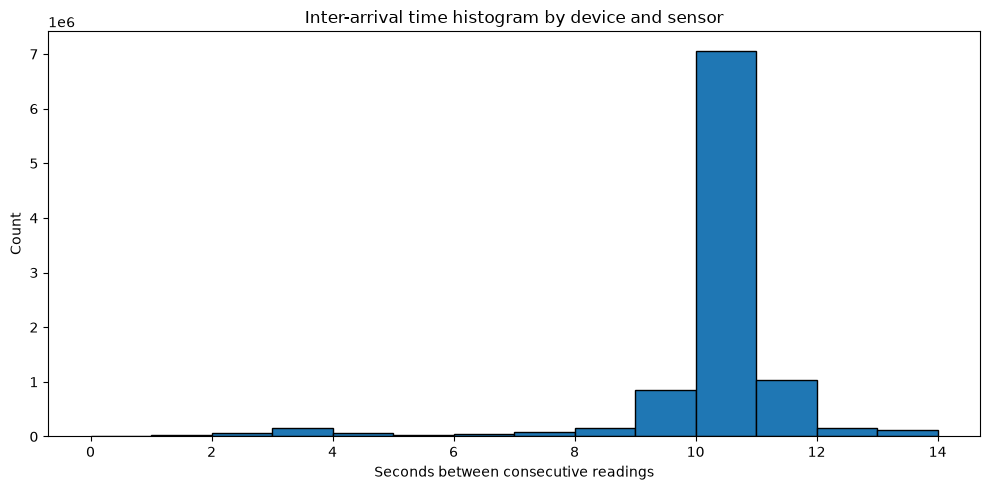

In [6]:
gap_seconds = (
    raw.sort_values(['DeviceId', 'Sensor', 'Time'])
       .groupby(['DeviceId', 'Sensor'])['Time']
       .diff()
       .dropna()
       .astype(float)
)

gap_seconds = gap_seconds[gap_seconds > 0]

print('Observed inter-arrival time distribution (seconds):')
display(gap_seconds.value_counts().sort_index().head(15))

plt.figure(figsize=(10, 5))
gap_seconds.plot(kind='hist', bins=range(0, 15), edgecolor='black')
plt.title('Inter-arrival time histogram by device and sensor')
plt.xlabel('Seconds between consecutive readings')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

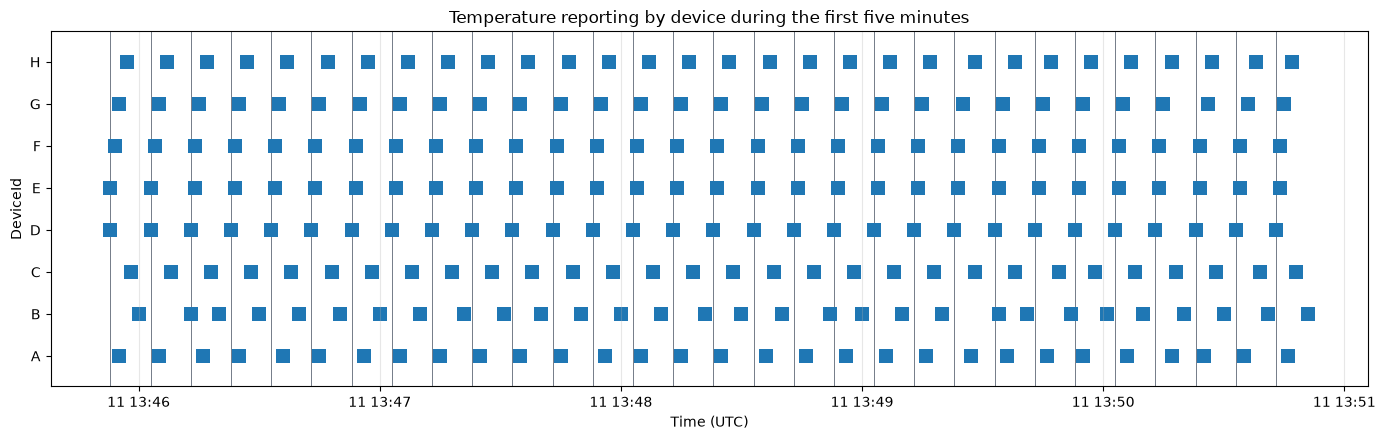

First five minutes: 2022-02-11 13:45:53+00:00 to 2022-02-11 13:50:53+00:00
Guide lines drawn: 30 at 10-second intervals
Unique device-second reports plotted: 240


In [26]:
first_five_minutes_start = temperature_raw['ts_utc'].min()
first_five_minutes_end = first_five_minutes_start + pd.Timedelta(minutes=5)
first_five_minutes = temperature_raw.loc[
    temperature_raw['ts_utc'].between(
        first_five_minutes_start,
        first_five_minutes_end,
        inclusive='left',
    ),
    ['Time', 'ts_utc', 'DeviceId'],
].drop_duplicates(['Time', 'DeviceId'])

device_order = sorted(first_five_minutes['DeviceId'].unique())
row_spacing = 0.55
device_positions = {
    device: position * row_spacing
    for position, device in enumerate(device_order)
}
y_positions = [device_positions[device] for device in device_order]

second_marks = pd.date_range(
    first_five_minutes_start,
    first_five_minutes_end,
    freq='10s',
    inclusive='left',
)

plt.figure(figsize=(14, 4.5))
plt.vlines(
    second_marks,
    ymin=-0.4,
    ymax=y_positions[-1] + 0.4,
    colors='#5b6573',
    linewidth=0.7,
    alpha=0.85,
    zorder=0,
)
plt.scatter(
    first_five_minutes['ts_utc'],
    first_five_minutes['DeviceId'].map(device_positions),
    marker='s',
    s=100,
    alpha=1,
    linewidths=0,
    zorder=1,
)
plt.yticks(y_positions, device_order)
plt.ylim(-0.4, y_positions[-1] + 0.4)
plt.xlabel('Time (UTC)')
plt.ylabel('DeviceId')
plt.title('Temperature reporting by device during the first five minutes')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'First five minutes: {first_five_minutes_start} to {first_five_minutes_end}')
print(f'Guide lines drawn: {len(second_marks)} at 10-second intervals')
print(f'Unique device-second reports plotted: {len(first_five_minutes):,}')

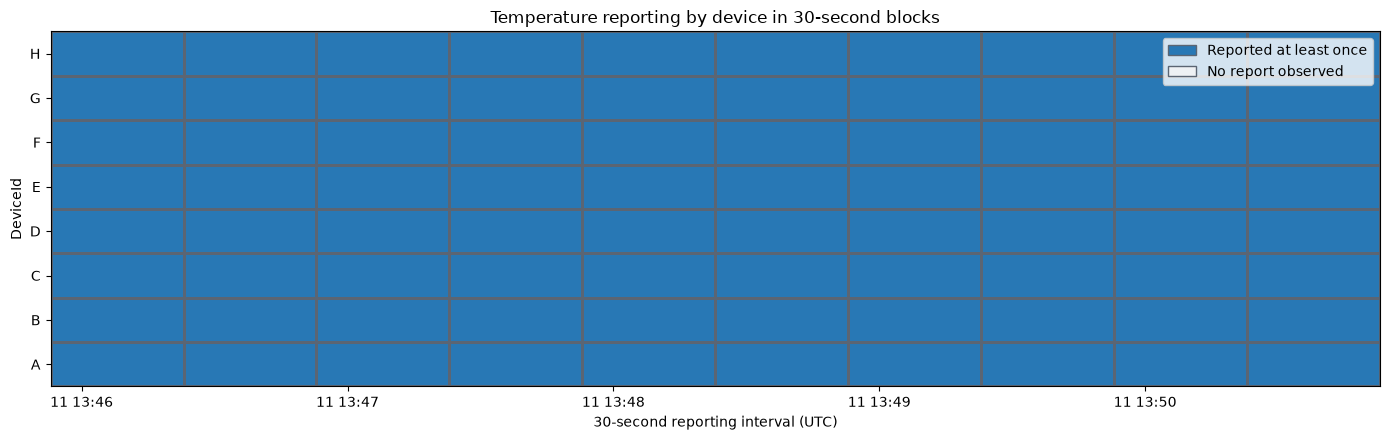

30-second blocks: 10
Blocks with at least one report: 80


In [27]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

block_size = pd.Timedelta(seconds=30)
block_edges = pd.date_range(
    first_five_minutes_start,
    first_five_minutes_end,
    freq=block_size,
)
block_count = len(block_edges) - 1

reports_30s = first_five_minutes.copy()
reports_30s['block_index'] = (
    (reports_30s['ts_utc'] - first_five_minutes_start).dt.total_seconds() // 30
).astype(int)

report_matrix = (
    reports_30s.assign(reported=1)
    .pivot_table(
        index='DeviceId',
        columns='block_index',
        values='reported',
        aggfunc='max',
        fill_value=0,
    )
    .reindex(index=device_order, columns=range(block_count), fill_value=0)
)

block_y_centers = [device_positions[device] for device in device_order]
block_y_edges = [
    block_y_centers[0] - row_spacing / 2,
    *[(left + right) / 2 for left, right in zip(block_y_centers, block_y_centers[1:])],
    block_y_centers[-1] + row_spacing / 2,
]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.pcolormesh(
    block_edges,
    block_y_edges,
    report_matrix.to_numpy(),
    cmap=ListedColormap(['#eef1f4', '#2878b5']),
    vmin=0,
    vmax=1,
    edgecolors='#5b6573',
    linewidth=0.8,
    shading='flat',
)
ax.set_yticks(block_y_centers, device_order)
ax.set_ylim(block_y_edges[0], block_y_edges[-1])
ax.set_xlabel('30-second reporting interval (UTC)')
ax.set_ylabel('DeviceId')
ax.set_title('Temperature reporting by device in 30-second blocks')
ax.legend(
    handles=[
        Patch(facecolor='#2878b5', edgecolor='#5b6573', label='Reported at least once'),
        Patch(facecolor='#eef1f4', edgecolor='#5b6573', label='No report observed'),
    ],
    loc='upper right',
)
fig.tight_layout()
plt.show()

print(f'30-second blocks: {block_count}')
print(f'Blocks with at least one report: {int(report_matrix.to_numpy().sum()):,}')

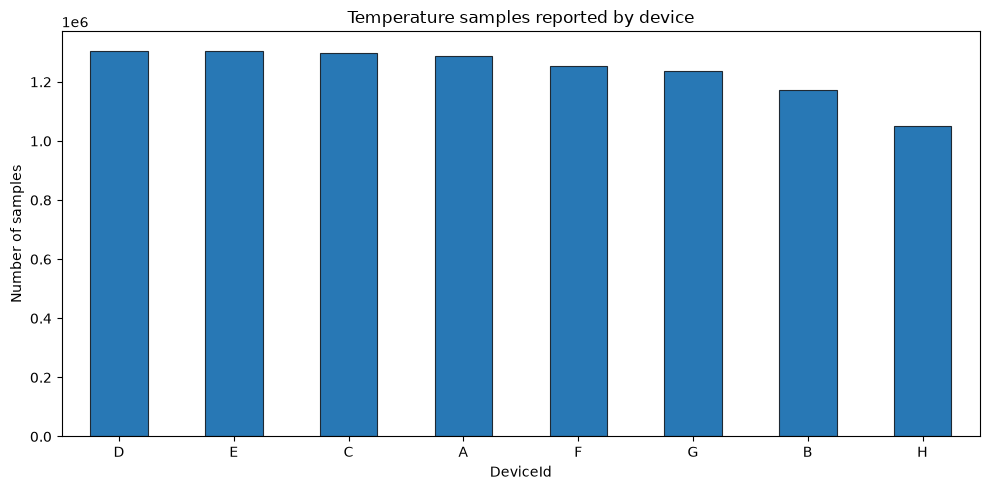

Total temperature samples counted: 9,909,343


In [28]:
samples_by_device = (
    temperature_raw.groupby('DeviceId')
    .size()
    .sort_values(ascending=False)
)

ax = samples_by_device.plot(
    kind='bar',
    figsize=(10, 5),
    color='#2878b5',
    edgecolor='#1f2933',
    linewidth=0.8,
)
ax.set_title('Temperature samples reported by device')
ax.set_xlabel('DeviceId')
ax.set_ylabel('Number of samples')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(f'Total temperature samples counted: {int(samples_by_device.sum()):,}')

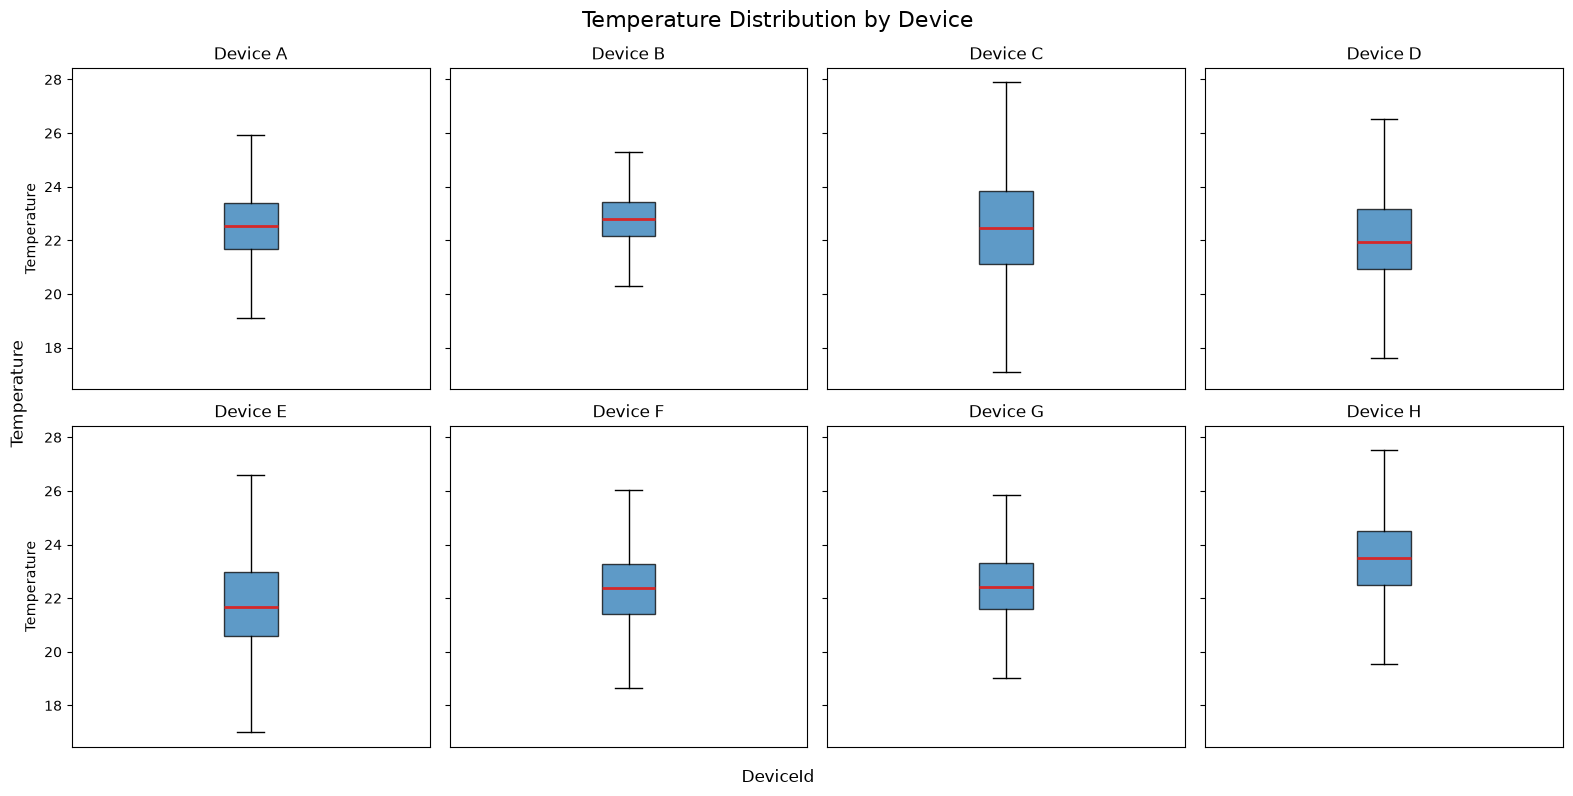

In [29]:
device_temperature = [
    temperature_raw.loc[temperature_raw['DeviceId'].eq(device), 'Value'].dropna()
    for device in device_order
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for ax, device, values in zip(axes, device_order, device_temperature):
    ax.boxplot(
        values,
        patch_artist=True,
        showfliers=False,
        boxprops={'facecolor': '#2878b5', 'alpha': 0.75},
        medianprops={'color': '#d62728', 'linewidth': 2},
    )
    ax.set_title(f'Device {device}')
    ax.set_xticks([])
    ax.set_ylabel('Temperature' if ax in axes[[0, 4]] else '')

fig.suptitle("Temperature Distribution by Device", fontsize=16)
fig.supxlabel("DeviceId")
fig.supylabel("Temperature")
fig.tight_layout()
plt.show()

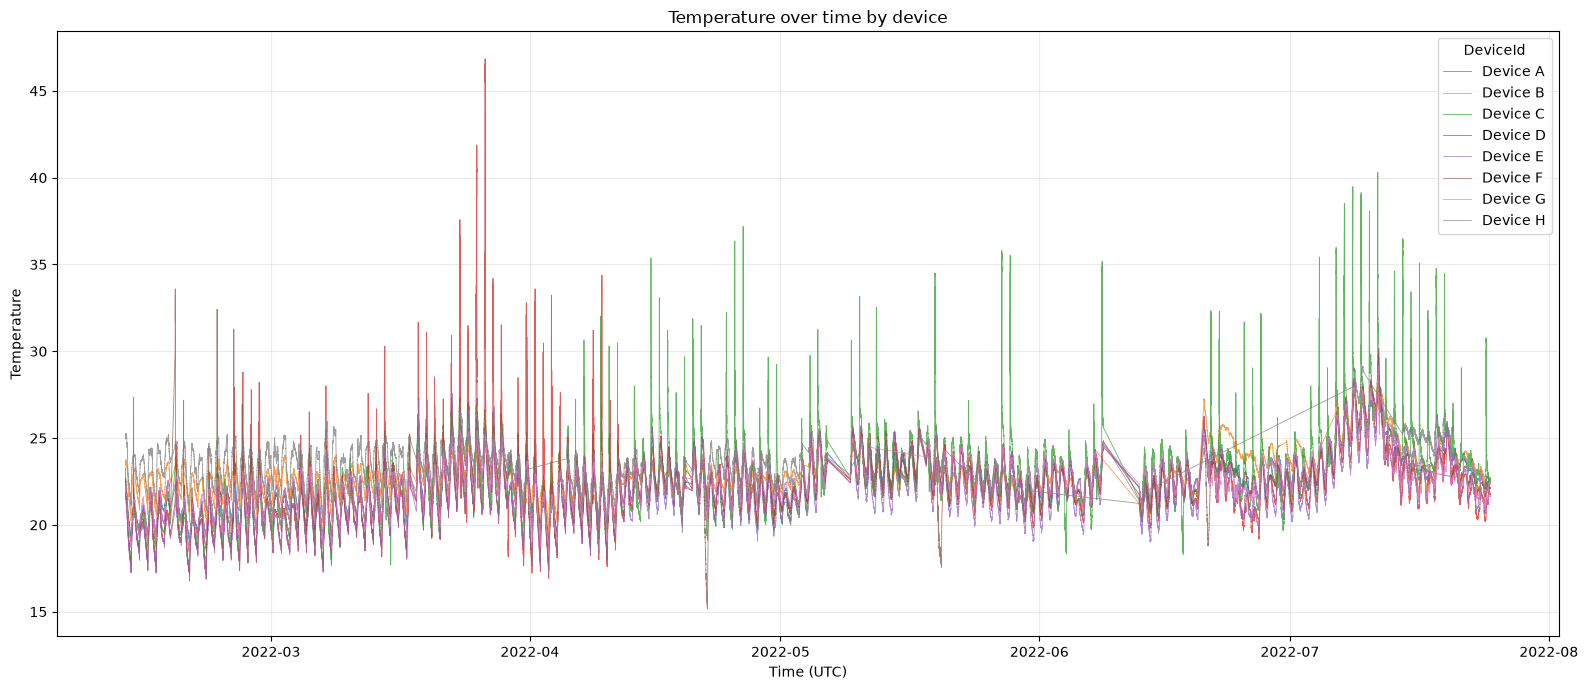

Device series plotted: 8
Total temperature samples plotted: 9,909,343


In [30]:
all_devices = sorted(temperature_raw['DeviceId'].unique())

fig, ax = plt.subplots(figsize=(16, 7))
for device in all_devices:
    device_data = temperature_raw.loc[
        temperature_raw['DeviceId'].eq(device)
    ].sort_values('ts_utc')
    ax.plot(
        device_data['ts_utc'],
        device_data['Value'],
        linewidth=0.6,
        alpha=0.75,
        label=f'Device {device}',
    )

ax.set_title('Temperature over time by device')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Temperature')
ax.legend(title='DeviceId')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(f'Device series plotted: {len(all_devices)}')
print(f'Total temperature samples plotted: {len(temperature_raw):,}')

In [32]:
device_temperature_summary = (
    temperature_raw.groupby('DeviceId')['Value']
    .agg(
        mean='mean',
        median='median',
        standard_deviation='std',
        first_quarter=lambda values: values.quantile(0.25),
        third_quarter=lambda values: values.quantile(0.75),
    )
    .sort_index()
    .round(2)
)

device_temperature_summary

,mean,median,standard_deviation,first_quarter,third_quarter
DeviceId,,,,,
A,22.57,22.55,1.38,21.67,23.39
B,22.93,22.78,1.28,22.17,23.42
C,22.60,22.47,2.21,21.12,23.83
D,22.11,21.95,1.96,20.94,23.17
E,21.82,21.68,1.80,20.59,23.00
F,22.41,22.36,1.60,21.42,23.27
G,22.47,22.42,1.45,21.58,23.30
H,23.53,23.51,1.40,22.48,24.50


In [7]:
n_rows = len(raw)
n_files = raw['source_file'].nunique()
n_devices = raw['DeviceId'].nunique()
n_sensors = raw['Sensor'].nunique()
start_ts = raw['ts_utc'].min()
end_ts = raw['ts_utc'].max()
span_hours = (end_ts - start_ts).total_seconds() / 3600

overview = pd.DataFrame({
    'metric': [
        'raw_rows',
        'raw_files',
        'unique_devices',
        'unique_sensors',
        'time_start_utc',
        'time_end_utc',
        'span_hours'
    ],
    'value': [
        n_rows,
        n_files,
        n_devices,
        n_sensors,
        start_ts,
        end_ts,
        round(span_hours, 2)
    ]
})
overview

,metric,value
0,raw_rows,79274744
1,raw_files,3471
2,unique_devices,8
3,unique_sensors,9
4,time_start_utc,2022-02-11 13:45:53+00:00
5,time_end_utc,2022-07-24 23:51:20+00:00
6,span_hours,3922.09


In [11]:
minute_counts = raw.groupby('minute_bucket').size().rename('records_per_minute')
minute_counts.describe()

count    218148.000000
mean        363.398903
std          46.225013
min           8.000000
25%         336.000000
50%         376.000000
75%         384.000000
max         544.000000
Name: records_per_minute, dtype: float64

In [ ]:
def score_monitoring_credibility(df: pd.DataFrame) -> pd.DataFrame:
    variability = (
        df.groupby('Sensor')['Value']
          .agg(['mean', 'std'])
          .reset_index()
    )
    variability['cv'] = variability['std'] / variability['mean'].replace(0, np.nan)
    variability['variability_score'] = np.clip(100 - (variability['cv'].fillna(0) * 100), 0, 100)
    variability['credibility_score'] = variability['variability_score']
    return variability.sort_values('credibility_score', ascending=False)

credibility = score_monitoring_credibility(raw)
credibility

,Sensor,coverage_pct,mean,std,cv,variability_score,quality_pct,credibility_score
3,IR,100.0,0.000000,0.000000,NaN,100.000000,100.0,100.000000
6,Pressure,100.0,101264.807371,893.386389,0.008822,99.117772,100.0,99.735332
8,Temperature,100.0,22.526268,1.739045,0.077201,92.279924,100.0,97.683977
7,RSSI,100.0,76.825840,10.564328,0.137510,86.248991,100.0,95.874697
2,Humidity,100.0,38.289236,8.235182,0.215078,78.492175,100.0,93.547652
5,MIC,100.0,2.600868,0.746116,0.286872,71.312805,100.0,91.393842
1,Gas,100.0,1838.109649,1641.379709,0.892972,10.702840,100.0,73.210852
0,Accelerometer,100.0,0.000540,0.023229,43.025735,0.000000,100.0,70.000000
4,Light,100.0,1218.335265,3061.749444,2.513060,0.000000,100.0,70.000000
